<a href="https://colab.research.google.com/github/AiswaryaV2006/QR_Code-Generator/blob/main/House_Price_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/House Price India.csv')

In [ ]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [ ]:
df.tail()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
14615,6762830250,42734,2,1.5,1556,20000,1.0,0,0,4,...,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14616,6762830339,42734,3,2.0,1680,7000,1.5,0,0,4,...,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14617,6762830618,42734,2,1.0,1070,6120,1.0,0,0,3,...,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14618,6762830709,42734,4,1.0,1030,6621,1.0,0,0,4,...,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000
14619,6762831463,42734,3,1.0,900,4770,1.0,0,0,3,...,1969,2009,122018,52.5338,-114.552,900,3480,2,55,146000


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (14620, 23)


In [ ]:
print(df.columns)

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')


In [ ]:
df.dtypes

,0
id,int64
Date,int64
number of bedrooms,int64
number of bathrooms,float64
living area,int64
lot area,int64
number of floors,float64
waterfront present,int64
number of views,int64
condition of the house,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [ ]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,...,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,6.762821e+09,42604.538646,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,0.007661,0.233105,3.430506,...,1970.926402,90.924008,122033.062244,52.792848,-114.404007,1996.702257,12753.500068,2.012244,64.950958,5.389322e+05
std,6.237575e+03,67.347991,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.087193,0.766259,0.664151,...,29.493625,416.216661,19.082418,0.137522,0.141326,691.093366,26058.414467,0.817284,8.936008,3.675324e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [ ]:
df.sample(5)

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
2600,6762830540,42532,4,1.75,1200,7680,1.0,0,0,3,...,1968,0,122023,52.5438,-114.382,1490,7800,1,50,210000
310,6762825420,42496,2,1.00,820,681,3.0,0,0,3,...,2006,0,122028,52.8919,-114.542,820,1156,2,56,339950
13414,6762829421,42706,3,2.25,1640,7630,1.0,0,0,4,...,1968,0,122066,52.6039,-114.480,1930,7630,3,64,247000
13688,6762826189,42712,3,1.75,1910,8329,1.0,0,0,3,...,2004,0,122068,52.4200,-114.206,2510,9259,1,50,323000
10559,6762827133,42655,3,2.50,1960,1477,2.0,0,0,3,...,2012,0,122015,52.7173,-114.356,1980,1467,2,70,300000


In [ ]:
df.isna()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14616,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14617,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14618,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
id,0
Date,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index([], dtype='object')


In [ ]:
df.dtypes

,0
id,int64
Date,int64
number of bedrooms,int64
number of bathrooms,float64
living area,int64
lot area,int64
number of floors,float64
waterfront present,int64
number of views,int64
condition of the house,int64


In [ ]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
numerical_columns = numerical_columns.drop(['id', 'Date', 'Postal Code', 'Renovation Year'])
print(numerical_columns)

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Lattitude', 'Longitude', 'living_area_renov',
       'lot_area_renov', 'Number of schools nearby',
       'Distance from the airport', 'Price'],
      dtype='object')


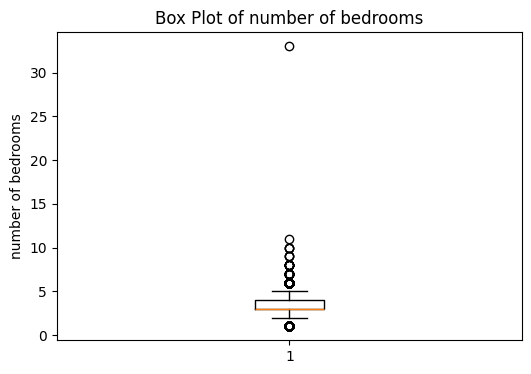

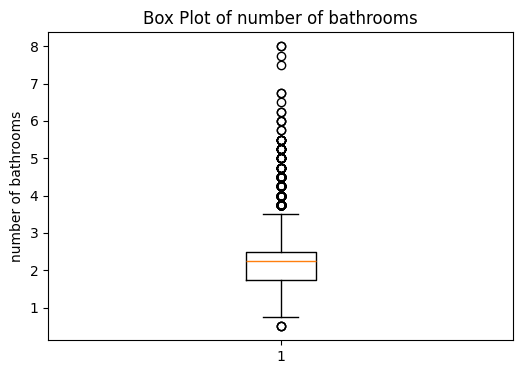

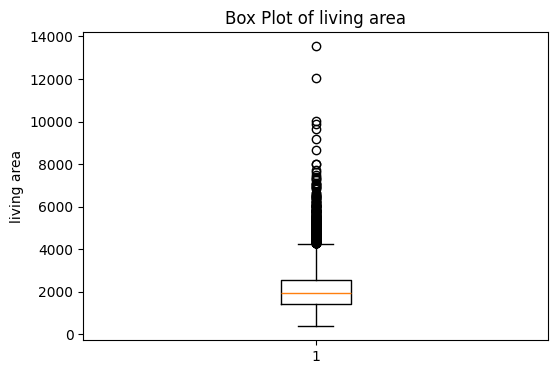

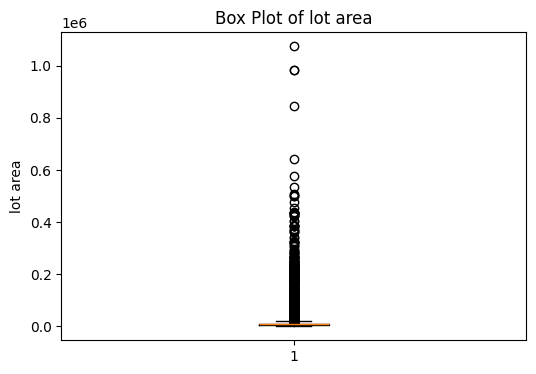

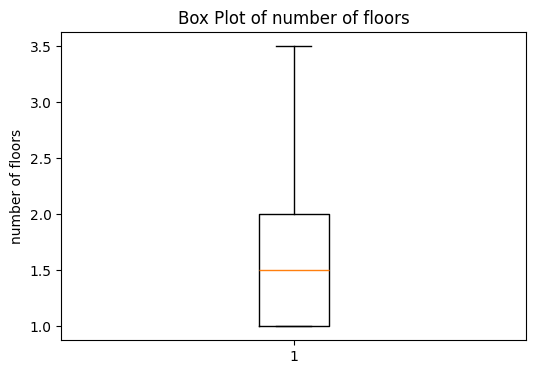

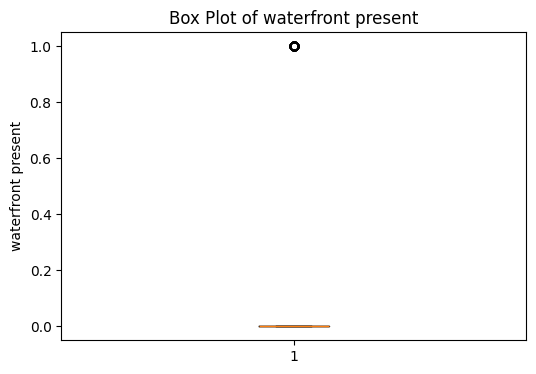

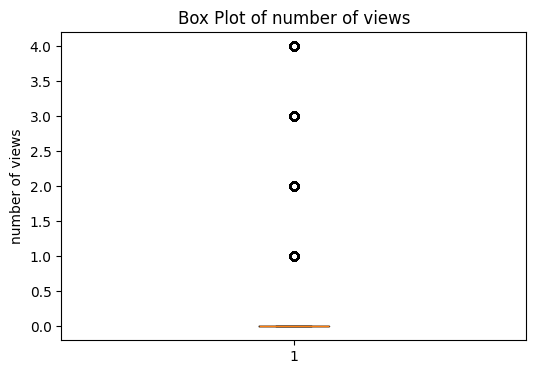

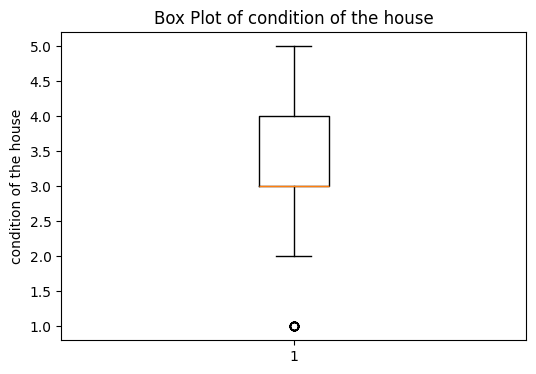

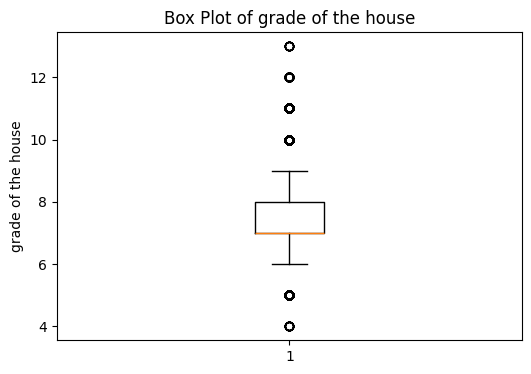

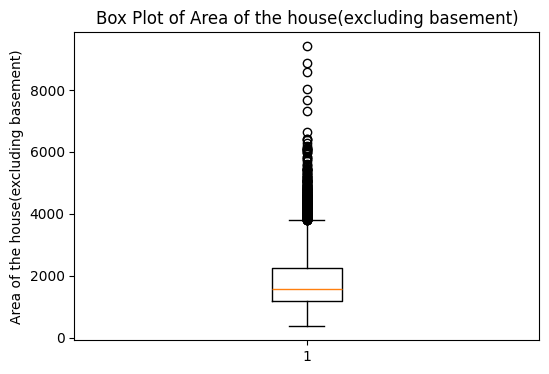

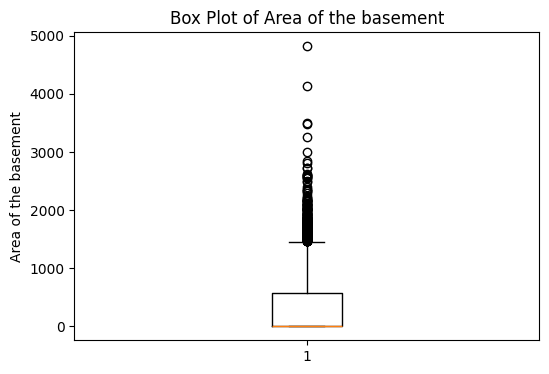

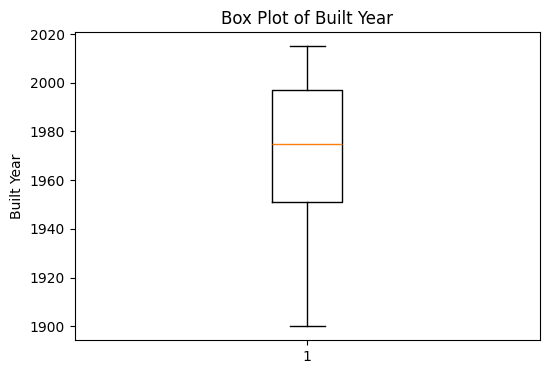

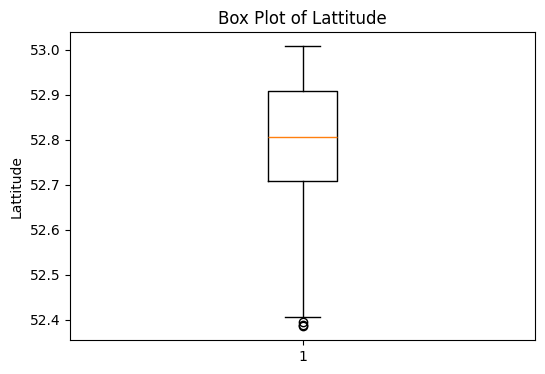

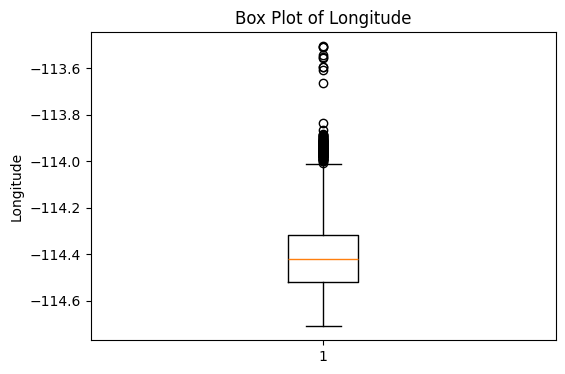

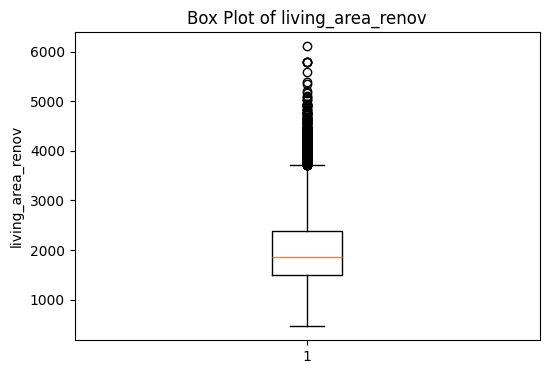

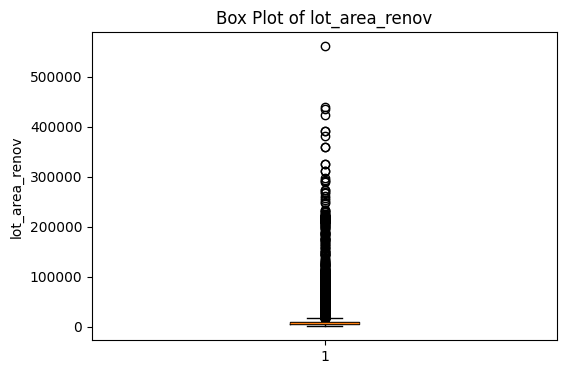

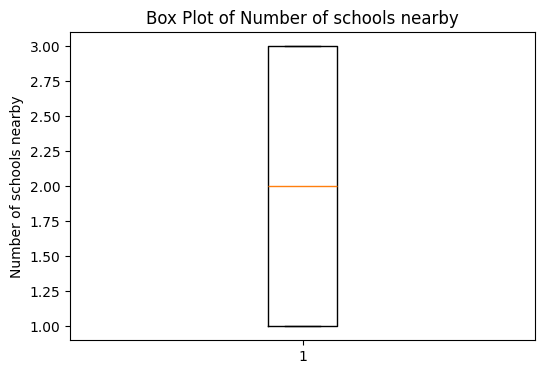

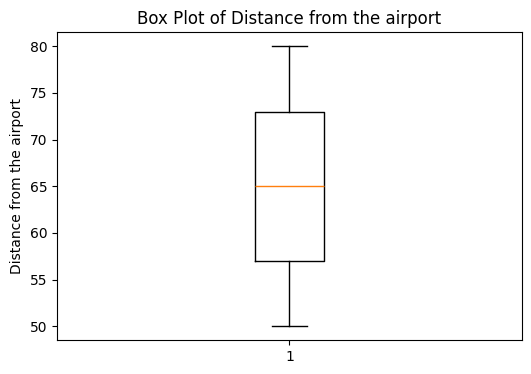

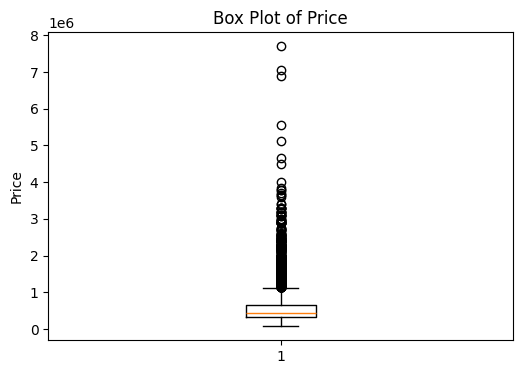

In [ ]:
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[column])
    plt.title(f"Box Plot of {column}")
    plt.ylabel(column)
    plt.show()
    print("\n")

In [ ]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column}: {len(outliers)} outliers")
    print('\n')

number of bedrooms: 361 outliers


number of bathrooms: 379 outliers


living area: 395 outliers


lot area: 1652 outliers


number of floors: 0 outliers


waterfront present: 112 outliers


number of views: 1422 outliers


condition of the house: 18 outliers


grade of the house: 1320 outliers


Area of the house(excluding basement): 402 outliers


Area of the basement: 287 outliers


Built Year: 0 outliers


Lattitude: 3 outliers


Longitude: 184 outliers


living_area_renov: 338 outliers


lot_area_renov: 1517 outliers


Number of schools nearby: 0 outliers


Distance from the airport: 0 outliers


Price: 761 outliers




In [ ]:
columns_to_treat = ['Price', 'living area', 'lot area']

In [ ]:
for column in columns_to_treat:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower_limit, upper_limit)

print("\nOutlier treatment completed successfully.")


Outlier treatment completed successfully.


In [ ]:
df.to_csv("House_Price_India_Outlier_Treated.csv", index=False)

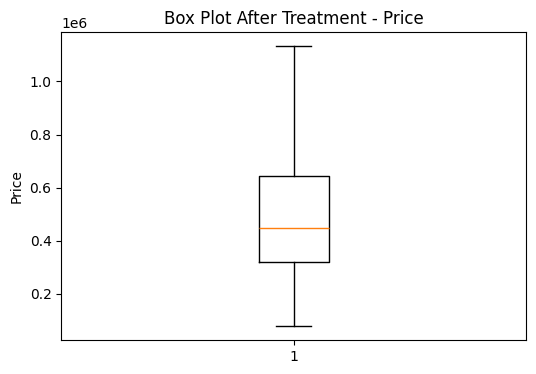

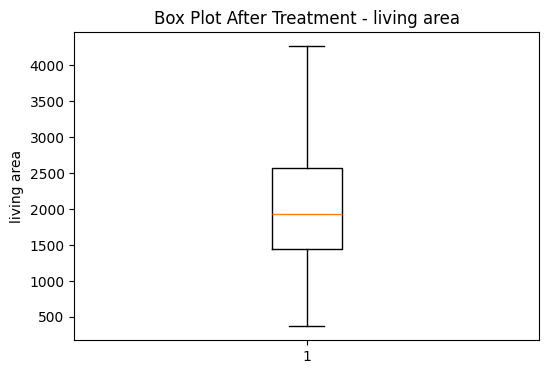

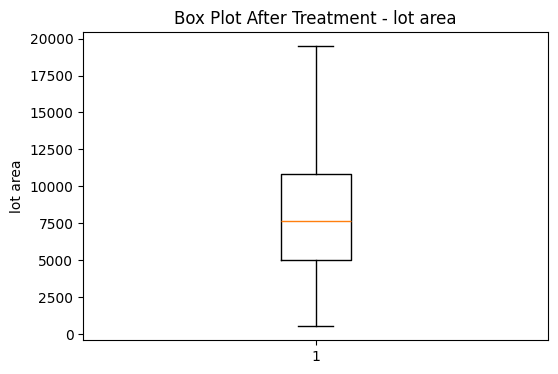

In [ ]:
for column in columns_to_treat:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[column])
    plt.title(f"Box Plot After Treatment - {column}")
    plt.ylabel(column)
    plt.show()

In [ ]:

print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,...,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,6.762821e+09,42604.538646,3.379343,2.129583,2075.891929,8760.293057,1.502360,0.007661,0.233105,3.430506,...,1970.926402,90.924008,122033.062244,52.792848,-114.404007,1996.702257,12753.500068,2.012244,64.950958,5.111526e+05
std,6.237575e+03,67.347991,0.938719,0.769934,845.427027,5157.345175,0.540239,0.087193,0.766259,0.664151,...,29.493625,416.216661,19.082418,0.137522,0.141326,691.093366,26058.414467,0.817284,8.936008,2.501552e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,520.000000,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5010.750000,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7620.000000,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,10800.000000,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,4265.000000,19483.875000,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,1.132500e+06


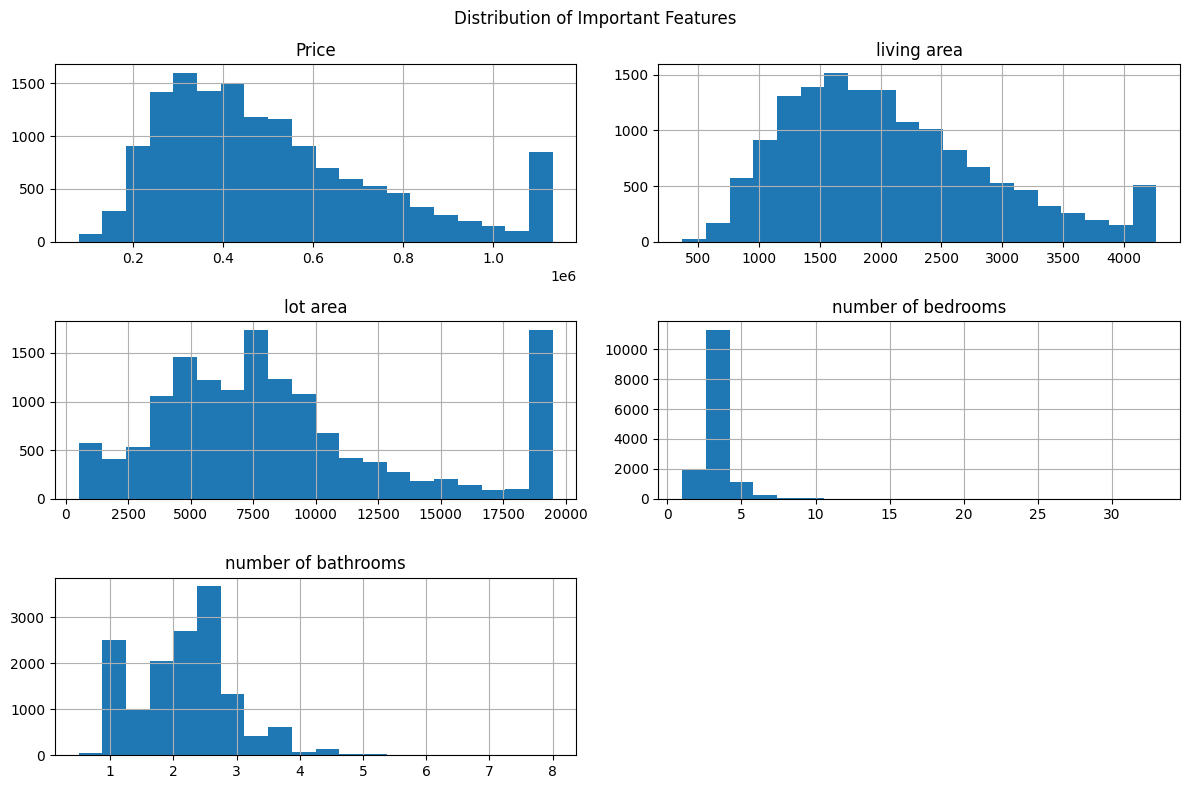

In [ ]:

features = ['Price', 'living area', 'lot area',
            'number of bedrooms', 'number of bathrooms']

df[features].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Important Features")
plt.tight_layout()
plt.show()

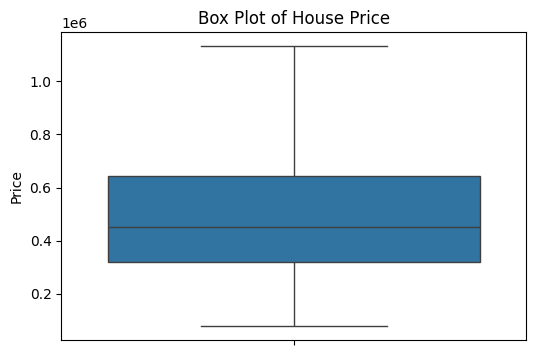

In [ ]:

plt.figure(figsize=(6,4))
sns.boxplot(y=df['Price'])
plt.title("Box Plot of House Price")
plt.show()

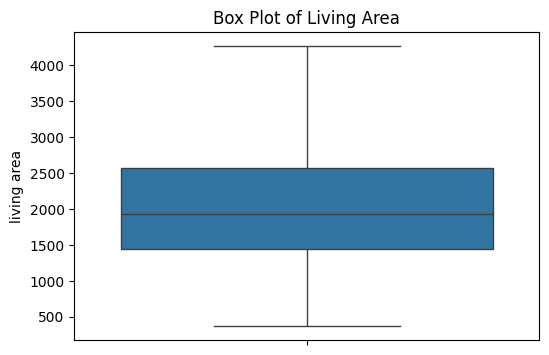

In [ ]:

plt.figure(figsize=(6,4))
sns.boxplot(y=df['living area'])
plt.title("Box Plot of Living Area")
plt.show()

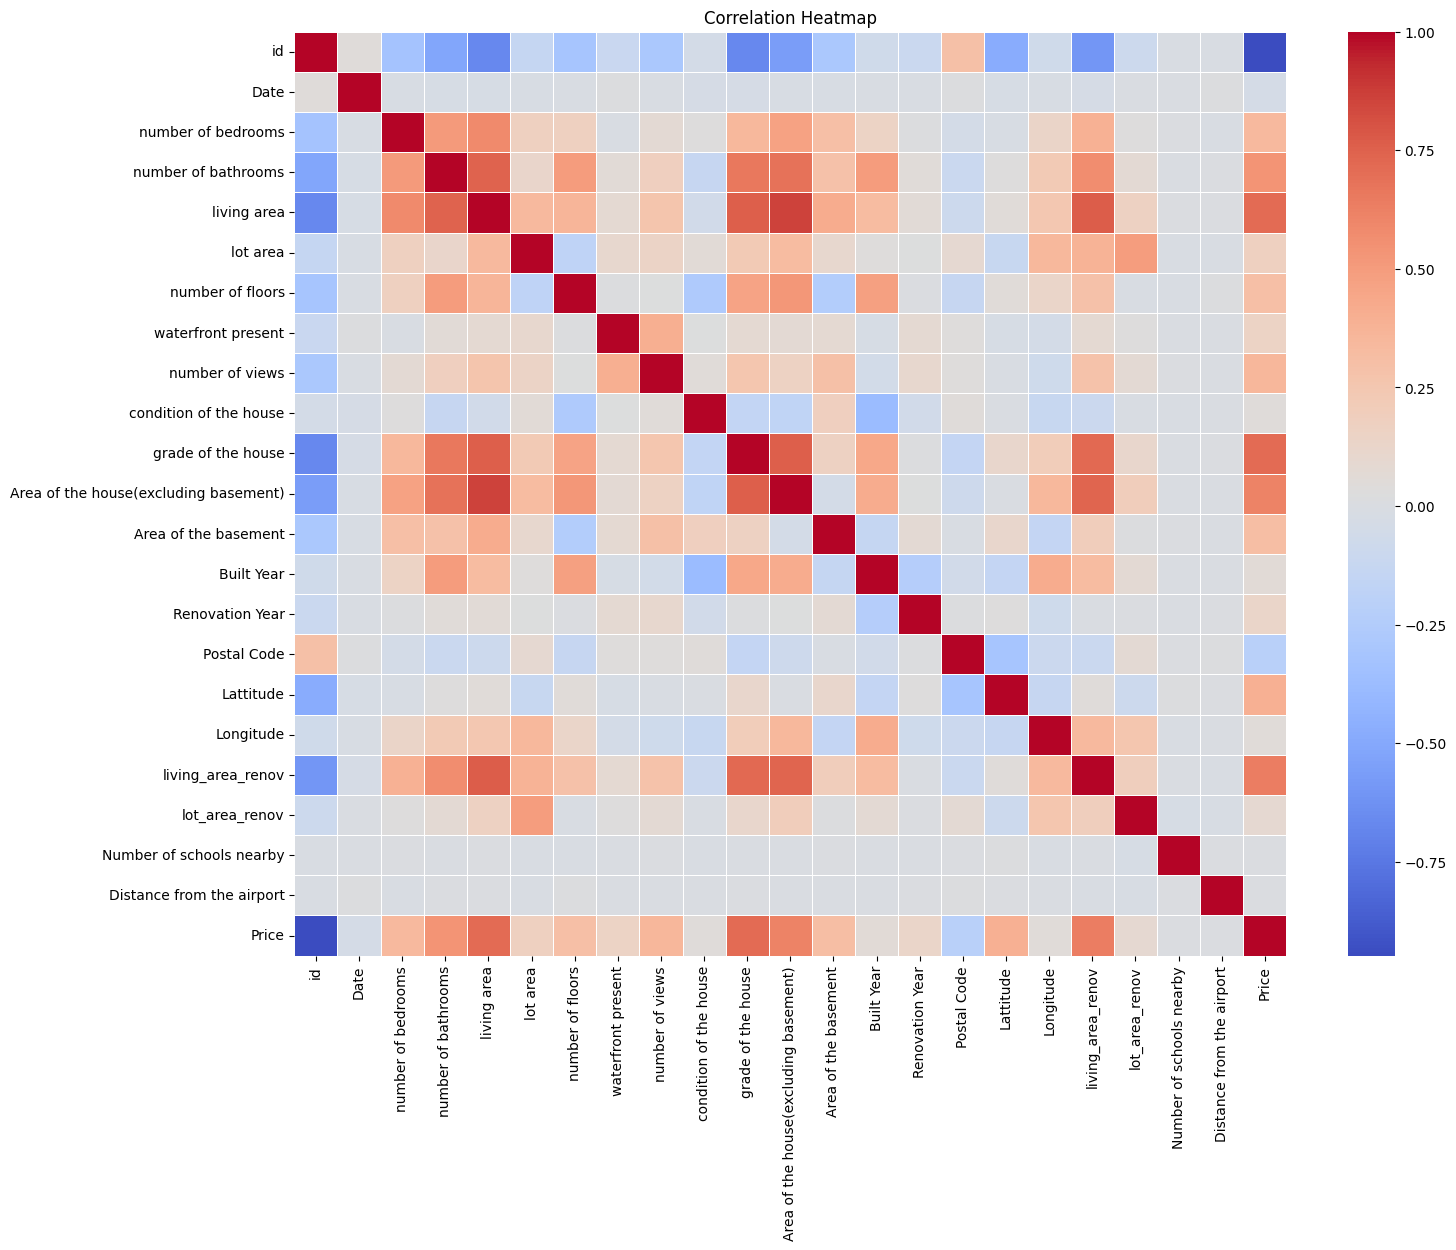

In [ ]:

plt.figure(figsize=(16,12))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap='coolwarm',
            annot=False,
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

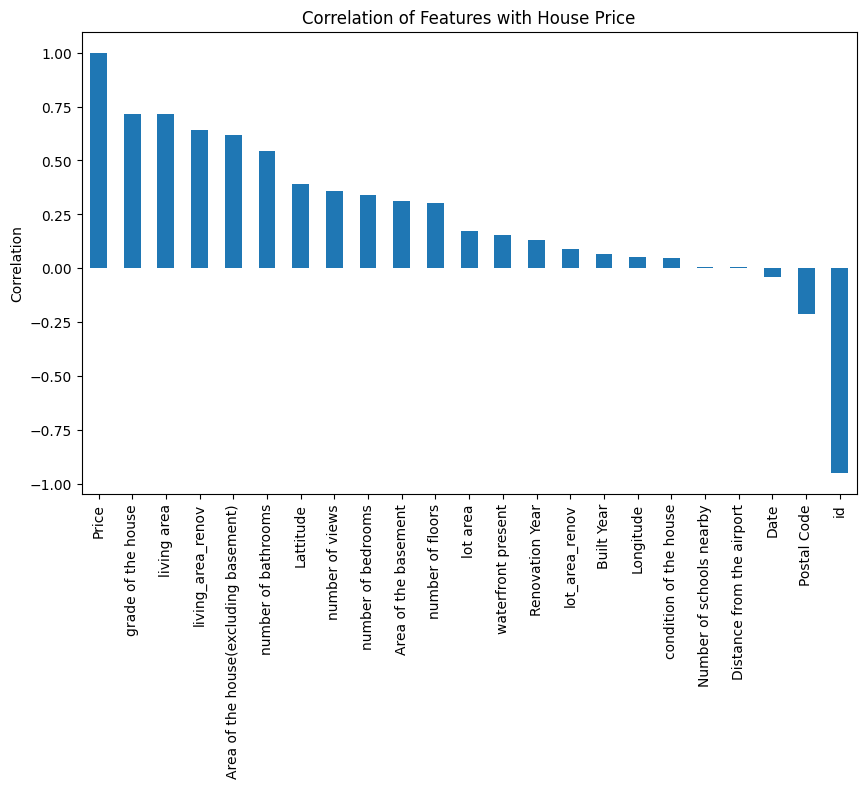

In [ ]:

price_corr = corr['Price'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
price_corr.plot(kind='bar')
plt.title("Correlation of Features with House Price")
plt.ylabel("Correlation")
plt.show()

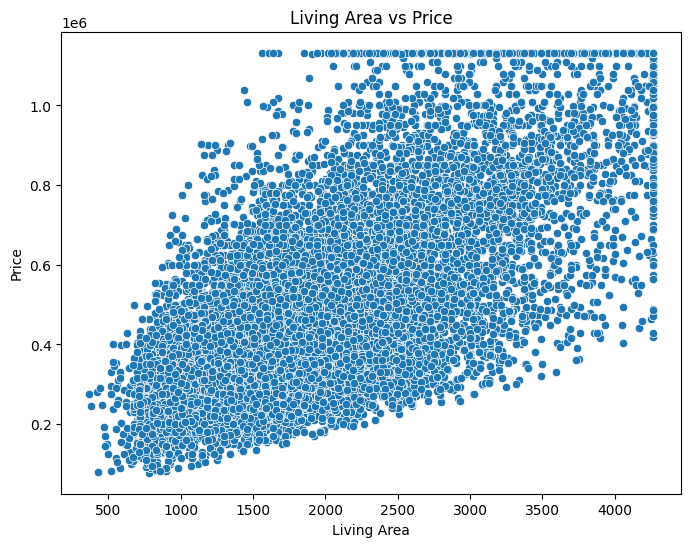

In [ ]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='living area',
    y='Price',
    data=df
)

plt.title("Living Area vs Price")
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.show()

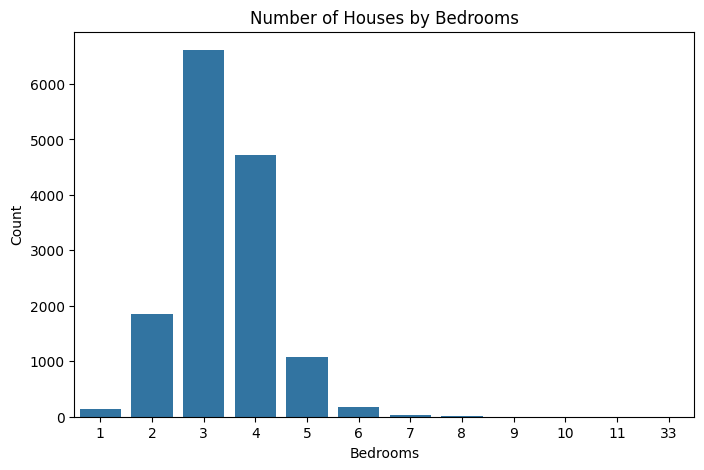

In [ ]:

plt.figure(figsize=(8,5))

sns.countplot(x='number of bedrooms', data=df)

plt.title("Number of Houses by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

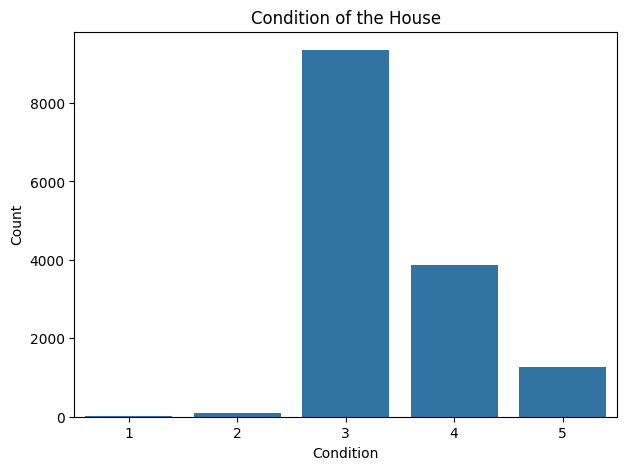

In [ ]:

plt.figure(figsize=(7,5))

sns.countplot(x='condition of the house', data=df)

plt.title("Condition of the House")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

In [ ]:
print("Key Insights:")
print("- Dataset contains 14,620 house records.")
print("- No missing values and no duplicate records.")
print("- Most houses have 3 or 4 bedrooms.")
print("- Living area has a strong positive relationship with house price.")
print("- Higher house grades generally correspond to higher prices.")
print("- Some outliers exist in Price and Lot Area, representing premium properties.")
print("- Correlation analysis shows that living area, house grade, and bathrooms are important features for predicting house price.")

Key Insights:
- Dataset contains 14,620 house records.
- No missing values and no duplicate records.
- Most houses have 3 or 4 bedrooms.
- Living area has a strong positive relationship with house price.
- Higher house grades generally correspond to higher prices.
- Some outliers exist in Price and Lot Area, representing premium properties.
- Correlation analysis shows that living area, house grade, and bathrooms are important features for predicting house price.


#Linear Regression

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv("/content/House_Price_India_Outlier_Treated.csv")

df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050.000,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,1132500
1,6762810635,42491,4,2.50,2920,4000.000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1132500
2,6762810998,42491,5,2.75,2910,9480.000,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1132500
3,6762812605,42491,4,2.50,3310,19483.875,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500.000,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [ ]:
X = df.drop(["Price","id","Date", "Postal Code", "Renovation Year"], axis=1)

y = df["Price"]

In [ ]:

print(X.columns)

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Lattitude', 'Longitude', 'living_area_renov',
       'lot_area_renov', 'Number of schools nearby',
       'Distance from the airport'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled)
print(X_test_scaled)

[[-0.41264256  0.4827619   0.50887459 ...  1.60103898  1.21026137
  -1.56937495]
 [ 0.69151379 -0.49367052 -0.94881312 ...  0.27844098 -0.01360315
   1.23576993]
 [ 0.69151379 -0.81914799 -0.16939643 ... -0.18993916 -1.23746766
   1.68459311]
 ...
 [-0.41264256  0.15728443  1.42513545 ... -0.18368129 -0.01360315
  -1.45716916]
 [-1.51679892  0.4827619  -0.9071649  ... -0.42869785 -1.23746766
  -0.447317  ]
 [-0.41264256 -0.49367052 -0.66917507 ... -0.28515085 -1.23746766
   1.57238732]]
[[-2.62095527 -0.81914799 -1.07375778 ... -0.42297747 -0.01360315
   1.01135834]
 [-0.41264256  0.4827619  -0.27649185 ... -0.10931635  1.21026137
  -1.00834598]
 [-1.51679892 -1.47010293 -0.6334766  ... -0.27678144  1.21026137
   0.78694675]
 ...
 [ 0.69151379  1.45919432  1.82971816 ... -0.33582805  1.21026137
   0.67474096]
 [-0.41264256 -0.81914799 -0.80006948 ... -0.19773269 -1.23746766
  -1.00834598]
 [ 1.79567014  0.15728443  0.98485426 ... -0.09395962 -1.23746766
  -0.89614018]]


In [ ]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [ ]:
y_pred = lr.predict(
    X_test_scaled
)

In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred)

In [ ]:
print("Linear Regression Performance")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE:", rmse)

print("R² Score:", r2)

Linear Regression Performance
MAE : 90420.66520970997
MSE : 14590254220.773857
RMSE: 120790.12468233427
R² Score: 0.7703406798506546


#KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [ ]:
knn_pred = knn.predict(X_test_scaled)

In [ ]:
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_mse = mean_squared_error(y_test, knn_pred)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_pred)

In [ ]:
print("KNN Regressor Performance")
print("MAE :", knn_mae)
print("MSE :", knn_mse)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)

KNN Regressor Performance
MAE : 76496.01251709987
MSE : 12118751580.411968
RMSE: 110085.2014596511
R² Score: 0.8092436083085193


#Decision Tree Regressor

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
dt_pred = dt.predict(X_test)

In [ ]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

In [ ]:
print("\nDecision Tree Regressor Performance")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)


Decision Tree Regressor Performance
MAE : 77356.37824897401
MSE : 13562279425.919289
RMSE: 116457.19997457988
R² Score: 0.7865216174097015


#Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Regressor Performance")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)


Random Forest Regressor Performance
MAE : 53934.14446648427
MSE : 6218703194.511736
RMSE: 78858.75471063271
R² Score: 0.9021138956010337


## Hyperparameter Tuning for Random Forest Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [ ]:

param_grid = {
    'n_estimators': [50, 100],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


rf_tuned = RandomForestRegressor(random_state=42)


random_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='r2',
    random_state=42
)


random_search.fit(X_train, y_train)


best_params = random_search.best_params_
best_rf_model = random_search.best_estimator_

print(f"Best Parameters: {best_params}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [ ]:

best_rf_pred = best_rf_model.predict(X_test)


best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_mse = mean_squared_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(best_rf_mse)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("\nTuned Random Forest Regressor Performance")
print("MAE :", best_rf_mae)
print("MSE :", best_rf_mse)
print("RMSE:", best_rf_rmse)
print("R² Score:", best_rf_r2)


Tuned Random Forest Regressor Performance
MAE : 58195.06505813953
MSE : 6951093662.936747
RMSE: 83373.21909904131
R² Score: 0.8905856319726412


#SVR



In [ ]:
from sklearn.svm import SVR

In [ ]:
svr = SVR()

In [ ]:
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

In [ ]:
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_pred)

print("\nSVR Performance")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)


SVR Performance
MAE : 194784.7159970948
MSE : 67263274487.34063
RMSE: 259351.64253835107
R² Score: -0.058764135020132


#Model Comparison and Model Selection

In [ ]:
import joblib

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'KNN Regressor',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Tuned Random Forest Regressor Performance',
        'Support Vector Regressor (SVR)'
    ],

    'MAE': [
        90346.29960701802,
        76969.84302325582,
        77623.39979480165,
        53805.071497949802,
        58131.28746580027,
        194787.1682095115
    ],

    'MSE': [
        14549195695.344398,
        12217035058.243952,
        13501653138.14535,
        6240799564.858822,
        7019058784.730728,
        67268006052.89537
    ],

    'RMSE': [
        120620.04682201213,
        110530.69735708697,
        116196.61414234646,
        78998.73141297158,
        83779.8232555472,
        259360.7642896191
    ],

    'R2 Score': [
        0.7709869655763026,
        0.8076965676360772,
        0.7874759114077812,
        0.9017660855276182,
        0.8895158203416108,
        -0.058838612689410486
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,90346.299607,1.454920e+10,120620.046822,0.770987
1,KNN Regressor,76969.843023,1.221704e+10,110530.697357,0.807697
2,Decision Tree Regressor,77623.399795,1.350165e+10,116196.614142,0.787476
3,Random Forest Regressor,53805.071498,6.240800e+09,78998.731413,0.901766
4,Tuned Random Forest Regressor Performance,58131.287466,7.019059e+09,83779.823256,0.889516
5,Support Vector Regressor (SVR),194787.168210,6.726801e+10,259360.764290,-0.058839


In [ ]:
print(results)

                                       Model            MAE           MSE  \
0                          Linear Regression   90346.299607  1.454920e+10   
1                              KNN Regressor   76969.843023  1.221704e+10   
2                    Decision Tree Regressor   77623.399795  1.350165e+10   
3                    Random Forest Regressor   53805.071498  6.240800e+09   
4  Tuned Random Forest Regressor Performance   58131.287466  7.019059e+09   
5             Support Vector Regressor (SVR)  194787.168210  6.726801e+10   

            RMSE  R2 Score  
0  120620.046822  0.770987  
1  110530.697357  0.807697  
2  116196.614142  0.787476  
3   78998.731413  0.901766  
4   83779.823256  0.889516  
5  259360.764290 -0.058839  


In [ ]:
best_model = results.loc[results['R2 Score'].idxmax()]

print(best_model)

Model       Random Forest Regressor
MAE                    53805.071498
MSE               6240799564.858822
RMSE                   78998.731413
R2 Score                   0.901766
Name: 3, dtype: object


In [ ]:
print("Best Model")
print(best_model)

Best Model
Model       Random Forest Regressor
MAE                    53805.071498
MSE               6240799564.858822
RMSE                   78998.731413
R2 Score                   0.901766
Name: 3, dtype: object


In [ ]:
print("Best Model is :", best_model["Model"])

Best Model is : Random Forest Regressor


In [ ]:
print("Best R² Score :", best_model["R2 Score"])

Best R² Score : 0.9017660855276182


In [ ]:
joblib.dump(best_rf_model, "house_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
model = joblib.load("house_price_model.pkl")

In [ ]:
!pip install streamlit pyngrok -q

In [ ]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

# -----------------------------
# Page Configuration
# -----------------------------
st.set_page_config(
    page_title="House Price Prediction",
    page_icon="🏠",
    layout="wide"
)

# -----------------------------
# Load Model
# -----------------------------
model = joblib.load("house_price_model.pkl")

# -----------------------------
# CSS Styling
# -----------------------------
st.markdown("""
<style>

.stApp{
    background-color:#E3F2FD;
}

/* Title */
h1{
    color:#1565C0 !important;
    text-align:center;
    font-size:45px !important;
    font-weight:bold;
}

/* Subtitle */
.subtitle{
    text-align:center;
    font-size:18px;
    color:#424242;
    margin-bottom:30px;
}

/* Input boxes */
div[data-testid="stNumberInput"]{
    background:white;
    padding:12px;
    border-radius:12px;
    box-shadow:0px 2px 8px rgba(0,0,0,0.08);
    margin-bottom:12px;
    transition: box-shadow 0.3s ease-in-out;
}

div[data-testid="stNumberInput"]:focus-within{
    box-shadow:0px 4px 12px rgba(0,0,0,0.15);
}

/* Button */
div.stButton > button{
    width:100%;
    background:#2196F3;
    color:white;
    height:55px;
    font-size:20px;
    font-weight:bold;
    border:none;
    border-radius:12px;
    transition: background 0.3s ease, transform 0.2s ease, box-shadow 0.3s ease;
}

div.stButton > button:hover{
    background:#1976D2;
    color:white;
    transform: scale(1.02);
    box-shadow:0px 4px 12px rgba(0,0,0,0.20);
}

/* Prediction box */
div[data-testid="stMarkdownContainer"] > div{
    background:#BBDEFB;
    padding:25px;
    border-radius:15px;
    text-align:center;
    font-size:28px;
    font-weight:bold;
    color:#1565C0;
    margin-top:20px;
    box-shadow:0px 4px 15px rgba(0,0,0,0.1);
}

</style>
""", unsafe_allow_html=True)


# -----------------------------
# Title
# -----------------------------
st.title("🏠 House Price Prediction")

st.markdown(
    "<p class='subtitle'>Predict the estimated price of a house using Machine Learning.</p>",
    unsafe_allow_html=True
)

# -----------------------------
# Input Fields
# -----------------------------
col1, col2 = st.columns(2)

with col1:
    bedrooms = st.number_input("Number of Bedrooms", min_value=0)
    bathrooms = st.number_input("Number of Bathrooms", min_value=0)
    living_area = st.number_input("Living Area", min_value=0.0)
    lot_area = st.number_input("Lot Area", min_value=0.0)
    floors = st.number_input("Number of Floors", min_value=1)
    waterfront = st.number_input("Waterfront Present (0/1)", min_value=0, max_value=1)
    views = st.number_input("Number of Views", min_value=0)
    condition = st.number_input("Condition of the House", min_value=1)
    grade = st.number_input("Grade of the House", min_value=1)

with col2:
    area_house = st.number_input("Area of House (excluding basement)", min_value=0.0)
    area_basement = st.number_input("Area of Basement", min_value=0.0)
    built_year = st.number_input("Built Year", min_value=1800)
    latitude = st.number_input("Lattitude")
    longitude = st.number_input("Longitude")
    living_area_renov = st.number_input("Living Area Renov", min_value=0.0)
    lot_area_renov = st.number_input("Lot Area Renov", min_value=0.0)
    schools = st.number_input("Number of Schools Nearby", min_value=0)
    airport = st.number_input("Distance from the Airport", min_value=0.0)

# -----------------------------
# Prediction
# -----------------------------
if st.button("Predict House Price"):

    input_data = pd.DataFrame({

        'number of bedrooms':[bedrooms],
        'number of bathrooms':[bathrooms],
        'living area':[living_area],
        'lot area':[lot_area],
        'number of floors':[floors],
        'waterfront present':[waterfront],
        'number of views':[views],
        'condition of the house':[condition],
        'grade of the house':[grade],
        'Area of the house(excluding basement)':[area_house],
        'Area of the basement':[area_basement],
        'Built Year':[built_year],
        'Lattitude':[latitude],
        'Longitude':[longitude],
        'living_area_renov':[living_area_renov],
        'lot_area_renov':[lot_area_renov],
        'Number of schools nearby':[schools],
        'Distance from the airport':[airport]

    })

    prediction = model.predict(input_data)

    st.markdown(f"""
    <div style="
    background:#BBDEFB;
    padding:25px;
    border-radius:15px;
    text-align:center;
    font-size:28px;
    font-weight:bold;
    color:#1565C0;
    margin-top:20px;
    box-shadow:0px 4px 15px rgba(0,0,0,0.1);">
    🏠 Estimated House Price <br><br>
    ₹ {prediction[0]:,.2f}
    </div>
    """, unsafe_allow_html=True)

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!pip install pyngrok -q

In [ ]:
ngrok.set_auth_token("3FLo5qVPH4zCrMVj902HT3DdNoZ_oTNUnGrCvscRuijKMt2B")

In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://crepe-sizzle-proofread.ngrok-free.dev" -> "http://localhost:8501"
